In [ ]:
!pip install -q transformers==4.46.3 sentencepiece accelerate \
datasets rouge-score bert-score sacrebleu sentence-transformers bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 54.7 MB/s eta 0:00:00


In [ ]:
import os
import gc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sacrebleu

from tqdm import tqdm
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    MBart50TokenizerFast,
    MBartForConditionalGeneration,
    BitsAndBytesConfig
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/ZEROSHOT_BENCHMARK_rest"

os.makedirs(BASE_DIR, exist_ok=True)

for model in ["mt5", "mbart", "bloomz", "sarvam"]:
    os.makedirs(f"{BASE_DIR}/{model}", exist_ok=True)

print(BASE_DIR)

/content/drive/MyDrive/ZEROSHOT_BENCHMARK_rest


In [ ]:
RUN_SPLIT = "validation"

In [ ]:
DATA_PATH = f"/content/drive/MyDrive/ZEROSHOT_BENCHMARK_rest/{RUN_SPLIT}.csv"

df = pd.read_csv(DATA_PATH)

df.dropna(subset=["article", "summary"], inplace=True)

df["article"] = df["article"].astype(str)
df["summary"] = df["summary"].astype(str)

print(df.shape)

(970, 3)


In [ ]:
semantic_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    device="cuda"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

In [ ]:
def compute_metrics(predictions, references):

    rouge = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=False
    )

    r1, r2, rl = [], [], []

    for ref, pred in zip(references, predictions):
        scores = rouge.score(ref, pred)

        r1.append(scores["rouge1"].fmeasure)
        r2.append(scores["rouge2"].fmeasure)
        rl.append(scores["rougeL"].fmeasure)

    bleu = sacrebleu.corpus_bleu(predictions, [references])

    pred_emb = semantic_model.encode(
        predictions,
        batch_size=32,
        convert_to_tensor=True
    )

    ref_emb = semantic_model.encode(
        references,
        batch_size=32,
        convert_to_tensor=True
    )

    semantic_scores = util.cos_sim(
        pred_emb,
        ref_emb
    ).diag().cpu().numpy()

    metrics_df = pd.DataFrame({
        "Metric": [
            "ROUGE-1",
            "ROUGE-2",
            "ROUGE-L",
            "BLEU",
            "BERTScore"
        ],
        "Score": [
            np.mean(r1),
            np.mean(r2),
            np.mean(rl),
            bleu.score,
            np.mean(semantic_scores)
        ]
    })

    rouge_df = pd.DataFrame({
        "ROUGE-1": r1,
        "ROUGE-2": r2,
        "ROUGE-L": rl
    })

    return metrics_df, rouge_df

In [ ]:
def save_outputs(model_name, predictions, references, articles):

    model_dir = f"{SAVE_DIR}/{model_name}"
    os.makedirs(model_dir, exist_ok=True)

    pred_df = pd.DataFrame({
        "Article": articles,
        "Reference": references,
        "Prediction": predictions
    })

    pred_df.to_csv(
        f"{model_dir}/predictions.csv",
        index=False
    )

    pred_df.sample(
        min(10, len(pred_df)),
        random_state=42
    ).to_csv(
        f"{model_dir}/sample_predictions.csv",
        index=False
    )

    metrics_df, rouge_df = compute_metrics(
        predictions,
        references
    )

    metrics_df.to_csv(
        f"{model_dir}/metrics.csv",
        index=False
    )

    rouge_df.to_csv(
        f"{model_dir}/rouge_scores.csv",
        index=False
    )

    plt.figure(figsize=(8,6))
    plt.bar(metrics_df["Metric"], metrics_df["Score"])
    plt.xticks(rotation=45)
    plt.title(f"{model_name.upper()} Metrics")
    plt.tight_layout()
    plt.savefig(f"{model_dir}/metrics_plot.png")
    plt.show()

    plt.figure(figsize=(8,6))
    plt.hist(rouge_df["ROUGE-1"], bins=30, alpha=0.6, label="ROUGE-1")
    plt.hist(rouge_df["ROUGE-2"], bins=30, alpha=0.6, label="ROUGE-2")
    plt.hist(rouge_df["ROUGE-L"], bins=30, alpha=0.6, label="ROUGE-L")
    plt.legend()
    plt.title(f"{model_name.upper()} ROUGE Distribution")
    plt.tight_layout()
    plt.savefig(f"{model_dir}/rouge_distribution.png")
    plt.show()

    with open(
        f"{model_dir}/report.txt",
        "w",
        encoding="utf-8"
    ) as f:
        for _, row in metrics_df.iterrows():
            f.write(f"{row['Metric']}: {row['Score']:.4f}\n")

    print(f"\n===== {model_name.upper()} METRICS =====")
    display(metrics_df)

    print("\n===== SAMPLE PREDICTIONS =====")
    display(pred_df.sample(min(5, len(pred_df)), random_state=42))

    print(f"\nSaved to: {model_dir}")

In [ ]:
clear_memory()

import gc
import torch
from transformers import MT5Tokenizer, MT5ForConditionalGeneration

gc.collect()
torch.cuda.empty_cache()

MODEL_NAME = "google/mt5-large"

tokenizer = MT5Tokenizer.from_pretrained(MODEL_NAME)

model = MT5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
).to("cuda")

model.eval()

print(type(model))

<class 'transformers.models.mt5.modeling_mt5.MT5ForConditionalGeneration'>


In [ ]:
BASE_DIR = "/content/drive/MyDrive/ZEROSHOT_BENCHMARK_rest"

RUN_SPLIT = "validation"   # or "test"

SAVE_DIR = f"{BASE_DIR}/{RUN_SPLIT}"

os.makedirs(SAVE_DIR, exist_ok=True)

for model in ["mt5", "mbart", "bloomz", "sarvam"]:
    os.makedirs(f"{SAVE_DIR}/{model}", exist_ok=True)

print(SAVE_DIR)

/content/drive/MyDrive/ZEROSHOT_BENCHMARK_rest/validation


In [ ]:
sample_df = df.sample(10, random_state=42).reset_index(drop=True)

100%|██████████| 970/970 [44:05<00:00,  2.73s/it]


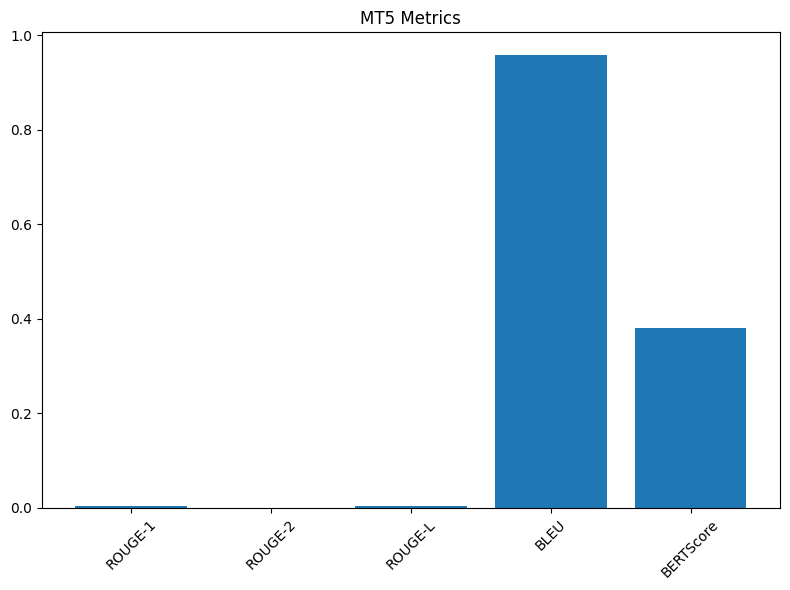

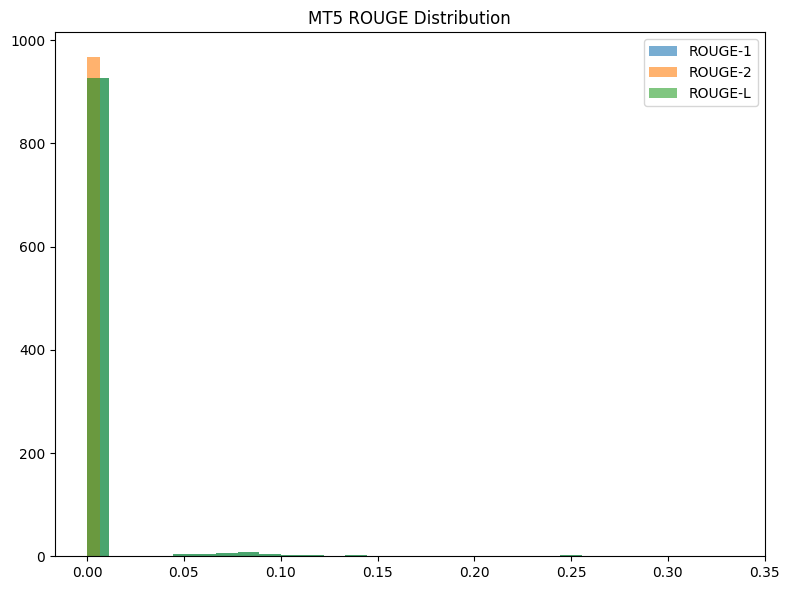


===== MT5 METRICS =====


,Metric,Score
0,ROUGE-1,0.004455
1,ROUGE-2,0.000436
2,ROUGE-L,0.004455
3,BLEU,0.957940
4,BERTScore,0.381141



===== SAMPLE PREDICTIONS =====


,Article,Reference,Prediction
575,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,<extra_id_0> ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സി...
259,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,<extra_id_0>. നിയമവാഴ്ച : നിയമവാഴ്ച്ച എന്നാൽ എ...
388,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,<extra_id_0>. <extra_id_1>. <extra_id_2>. <e...
495,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,<extra_id_0> ശിവസേനയുടെ നയം വ്യക്തമാക്കി <extr...
70,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,<extra_id_0>. <extra_id_1>. . <extra_id_2>. ...



Saved to: /content/drive/MyDrive/ZEROSHOT_BENCHMARK_rest/validation/mt5


In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    article = row["article"]
    reference = row["summary"]
    prompt = f"""
summarize text:
{article}
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
        **inputs,
        max_new_tokens=48,
        num_beams=2,
        repetition_penalty=1.1,
        no_repeat_ngram_size=3,
        early_stopping=True
    )

    pred = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

save_outputs("mt5", predictions, references, articles)

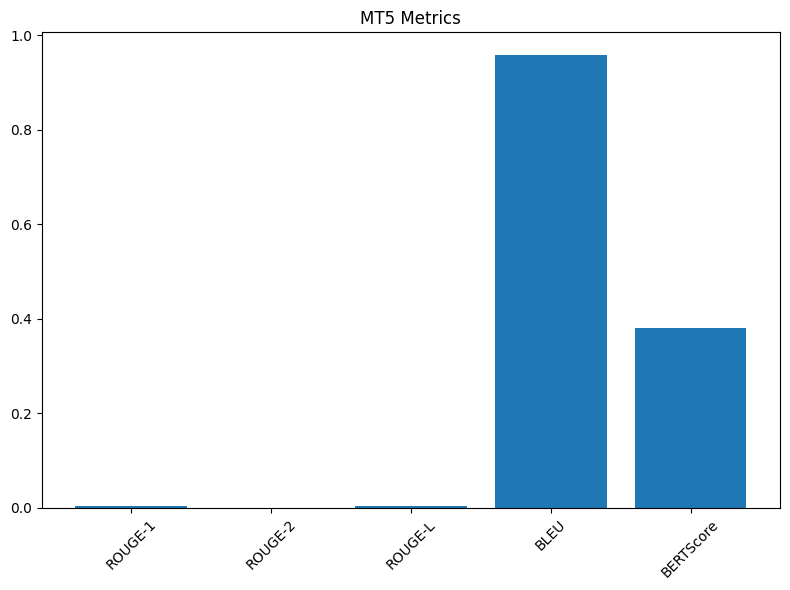

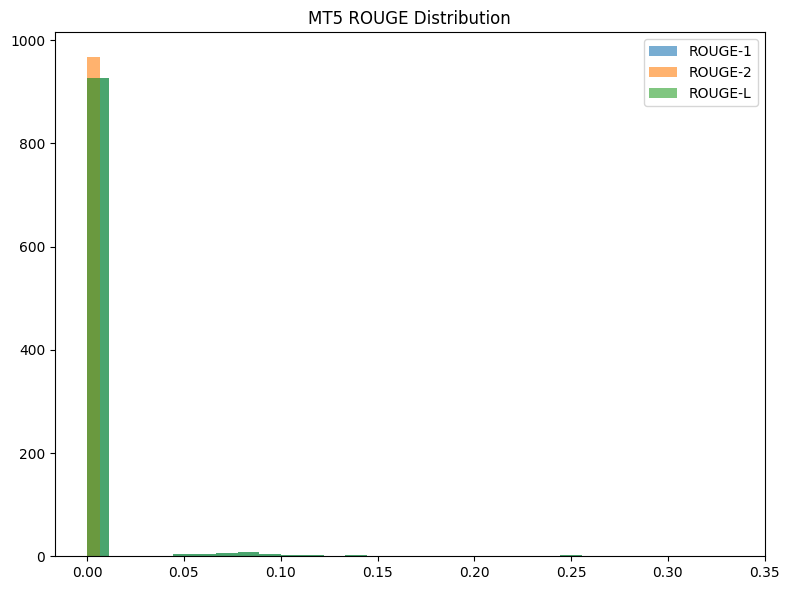


===== MT5 METRICS =====


,Metric,Score
0,ROUGE-1,0.004455
1,ROUGE-2,0.000436
2,ROUGE-L,0.004455
3,BLEU,0.957940
4,BERTScore,0.381141



===== SAMPLE PREDICTIONS =====


,Article,Reference,Prediction
575,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,<extra_id_0> ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സി...
259,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,<extra_id_0>. നിയമവാഴ്ച : നിയമവാഴ്ച്ച എന്നാൽ എ...
388,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,<extra_id_0>. <extra_id_1>. <extra_id_2>. <e...
495,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,<extra_id_0> ശിവസേനയുടെ നയം വ്യക്തമാക്കി <extr...
70,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,<extra_id_0>. <extra_id_1>. . <extra_id_2>. ...



Saved to: /content/drive/MyDrive/ZEROSHOT_BENCHMARK_rest/validation/mt5


In [ ]:
save_outputs("mt5", predictions, references, articles)

In [ ]:
clear_memory()

from transformers import MBart50TokenizerFast, MBartForConditionalGeneration

MODEL = "facebook/mbart-large-50-many-to-many-mmt"

tokenizer = MBart50TokenizerFast.from_pretrained(MODEL)

model = MBartForConditionalGeneration.from_pretrained(MODEL).to("cuda")

tokenizer.src_lang = "ml_IN"
tokenizer.tgt_lang = "ml_IN"

model.eval()

MBartForConditionalGeneration(
  (model): MBartModel(
    (shared): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
    (encoder): MBartEncoder(
      (embed_tokens): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
      (embed_positions): MBartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x MBartEncoderLayer(
          (self_attn): MBartSdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
    

In [ ]:
sample_df = df.sample(10, random_state=42).reset_index(drop=True)

In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    article = row["article"]
    reference = row["summary"]

    prompt = f"""
താഴെ കൊടുത്തിരിക്കുന്ന മലയാളം വാർത്ത സംക്ഷിപ്തമായി മലയാളത്തിൽ സംഗ്രഹിക്കൂ.

വാർത്ത:
{article}

സംഗ്രഹം:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            num_beams=4,
            forced_bos_token_id=tokenizer.lang_code_to_id["ml_IN"],
            early_stopping=True
        )

    pred = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

  0%|          | 0/10 [00:00<?, ?it/s]


AttributeError: 'str' object has no attribute 'generate'

In [ ]:
clear_memory()

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

MODEL = "bigscience/bloomz-560m"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb,
    device_map="auto"
)

model.eval()

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

BloomForCausalLM(
  (transformer): BloomModel(
    (word_embeddings): Embedding(250880, 1024)
    (word_embeddings_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (h): ModuleList(
      (0-23): 24 x BloomBlock(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (self_attention): BloomAttention(
          (query_key_value): Linear4bit(in_features=1024, out_features=3072, bias=True)
          (dense): Linear4bit(in_features=1024, out_features=1024, bias=True)
          (attention_dropout): Dropout(p=0.0, inplace=False)
        )
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): BloomMLP(
          (dense_h_to_4h): Linear4bit(in_features=1024, out_features=4096, bias=True)
          (gelu_impl): BloomGelu()
          (dense_4h_to_h): Linear4bit(in_features=4096, out_features=1024, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affi

100%|██████████| 970/970 [20:32<00:00,  1.27s/it]


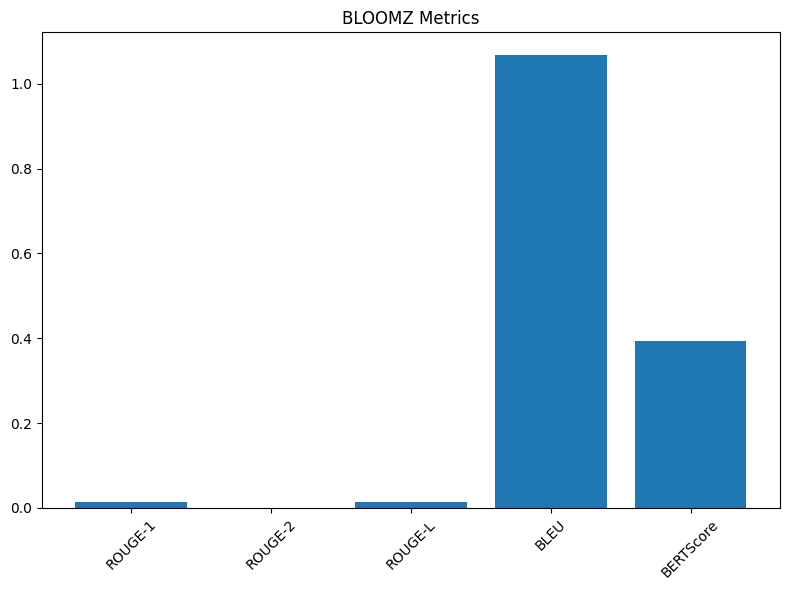

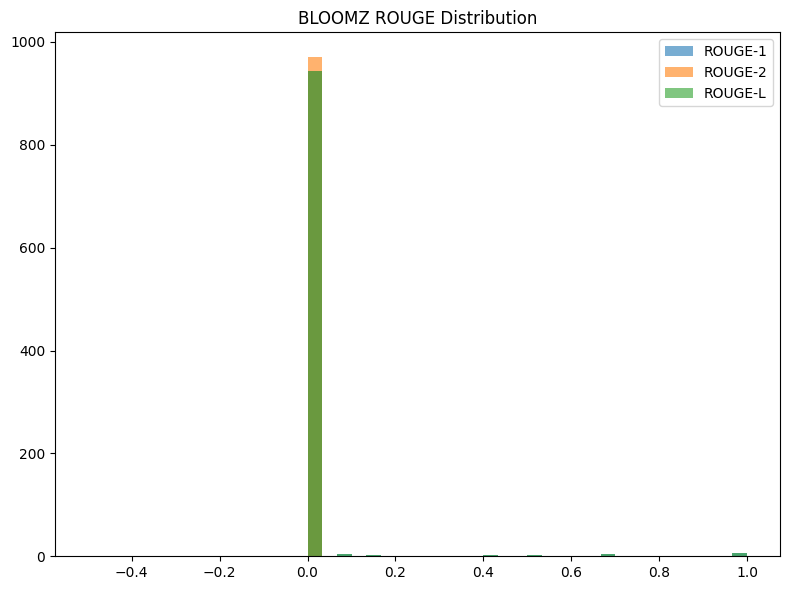


===== BLOOMZ METRICS =====


,Metric,Score
0,ROUGE-1,0.013840
1,ROUGE-2,0.000000
2,ROUGE-L,0.013840
3,BLEU,1.068298
4,BERTScore,0.394508



===== SAMPLE PREDICTIONS =====


,Article,Reference,Prediction
575,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,nic.gov.bd : ''nic.gov.bd: ''nic.gov.bd: ''nic...
259,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,'law and order'
388,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന നഗരം വ...
495,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,ദില്ലി: 1971-ലെ പാര്‌ലമെന്റിന്റെ ശൈത്യകാല സെ...
70,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,mondiauxia : കോ ത മം ഗ ലം മാ



Saved to: /content/drive/MyDrive/ZEROSHOT_BENCHMARK/validation/bloomz


In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    article = row["article"]
    reference = row["summary"]

    prompt = f"""
Summarize this Malayalam news article in Malayalam.

Article:
{article}

Summary:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=48,
            do_sample=False
        )

    generated = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    pred = generated.split("Summary:")[-1].strip()

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

save_outputs("bloomz", predictions, references, articles)